# 02 IOU Results

This notebook displays quantitative IOU, Precision, Recall, F1, and segment-count results for the proposed method against manual labels. It does not run the reconstruction algorithm.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

IOU_DIR = REPO_ROOT / "data_iou"
YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

print("REPO_ROOT:", REPO_ROOT)
print("IOU_DIR:", IOU_DIR)


REPO_ROOT: e:\论文提交代码5.24\CODE_CE4
IOU_DIR: e:\论文提交代码5.24\CODE_CE4\data_iou


## Proposed Method vs Manual Labels

`manual*.csv` are manual labels. `auto2019.csv`, `auto2020.csv`, etc. are the proposed method results.


In [2]:
from ce4_lpr.metrics import evaluate_years, phase_summary

results = evaluate_years(IOU_DIR, YEARS, pred_prefix="auto", ref_prefix="manual")
display(results)

summary = phase_summary(results)
display(summary)


,Year,IOU,Precision,Recall,F1_Score,Accuracy,TP_points,FP_points,FN_points,Manual_Count,Pred_Count,Matched_Segments,Segment_Recall,Count_Diff
0,2019,0.9547,0.9605,0.9937,0.9768,0.9972,8560,352,54,68,68,67,0.9853,0
1,2020,0.9691,0.9702,0.9987,0.9843,0.9982,6391,196,8,49,49,49,1.0000,0
2,2021,0.9582,0.9652,0.9925,0.9786,0.9973,10336,373,78,78,80,78,1.0000,2
3,2022,0.9518,0.9570,0.9943,0.9753,0.9964,11080,498,63,90,90,90,1.0000,0
4,2023,0.9266,0.9455,0.9790,0.9619,0.9975,3259,188,70,39,39,38,0.9744,0
5,2024,0.9570,0.9622,0.9944,0.9780,0.9988,712,28,4,10,10,10,1.0000,0


,Phase,Avg_Precision,Avg_Recall,Avg_IOU,Avg_F1,Total_Count_Error
0,Calibration (2019-2022),0.9632,0.9948,0.9585,0.9788,2
1,Test Set (2023-2024),0.9539,0.9867,0.9418,0.9700,0
2,All Chang'e-4 (2019-2024),0.9601,0.9921,0.9529,0.9758,2


## Compact Paper-Style Table

This table keeps the key columns used for reporting the proposed method performance.


In [3]:
compact = results[[
    "Year", "Precision", "Recall", "IOU", "F1_Score",
    "Manual_Count", "Pred_Count", "Count_Diff"
]].copy()
display(compact)

all_avg_f1 = summary.loc[summary["Phase"] == "All Chang'e-4 (2019-2024)", "Avg_F1"].iloc[0]
all_avg_iou = summary.loc[summary["Phase"] == "All Chang'e-4 (2019-2024)", "Avg_IOU"].iloc[0]
print("All-year average F1:", all_avg_f1)
print("All-year average IOU:", all_avg_iou)


,Year,Precision,Recall,IOU,F1_Score,Manual_Count,Pred_Count,Count_Diff
0,2019,0.9605,0.9937,0.9547,0.9768,68,68,0
1,2020,0.9702,0.9987,0.9691,0.9843,49,49,0
2,2021,0.9652,0.9925,0.9582,0.9786,78,80,2
3,2022,0.9570,0.9943,0.9518,0.9753,90,90,0
4,2023,0.9455,0.9790,0.9266,0.9619,39,39,0
5,2024,0.9622,0.9944,0.9570,0.9780,10,10,0


All-year average F1: 0.9758
All-year average IOU: 0.9529


## Plot Annual F1 and Count Difference


Saved figure: e:\论文提交代码5.24\CODE_CE4\outputs\iou_results\annual_f1_count_difference.png


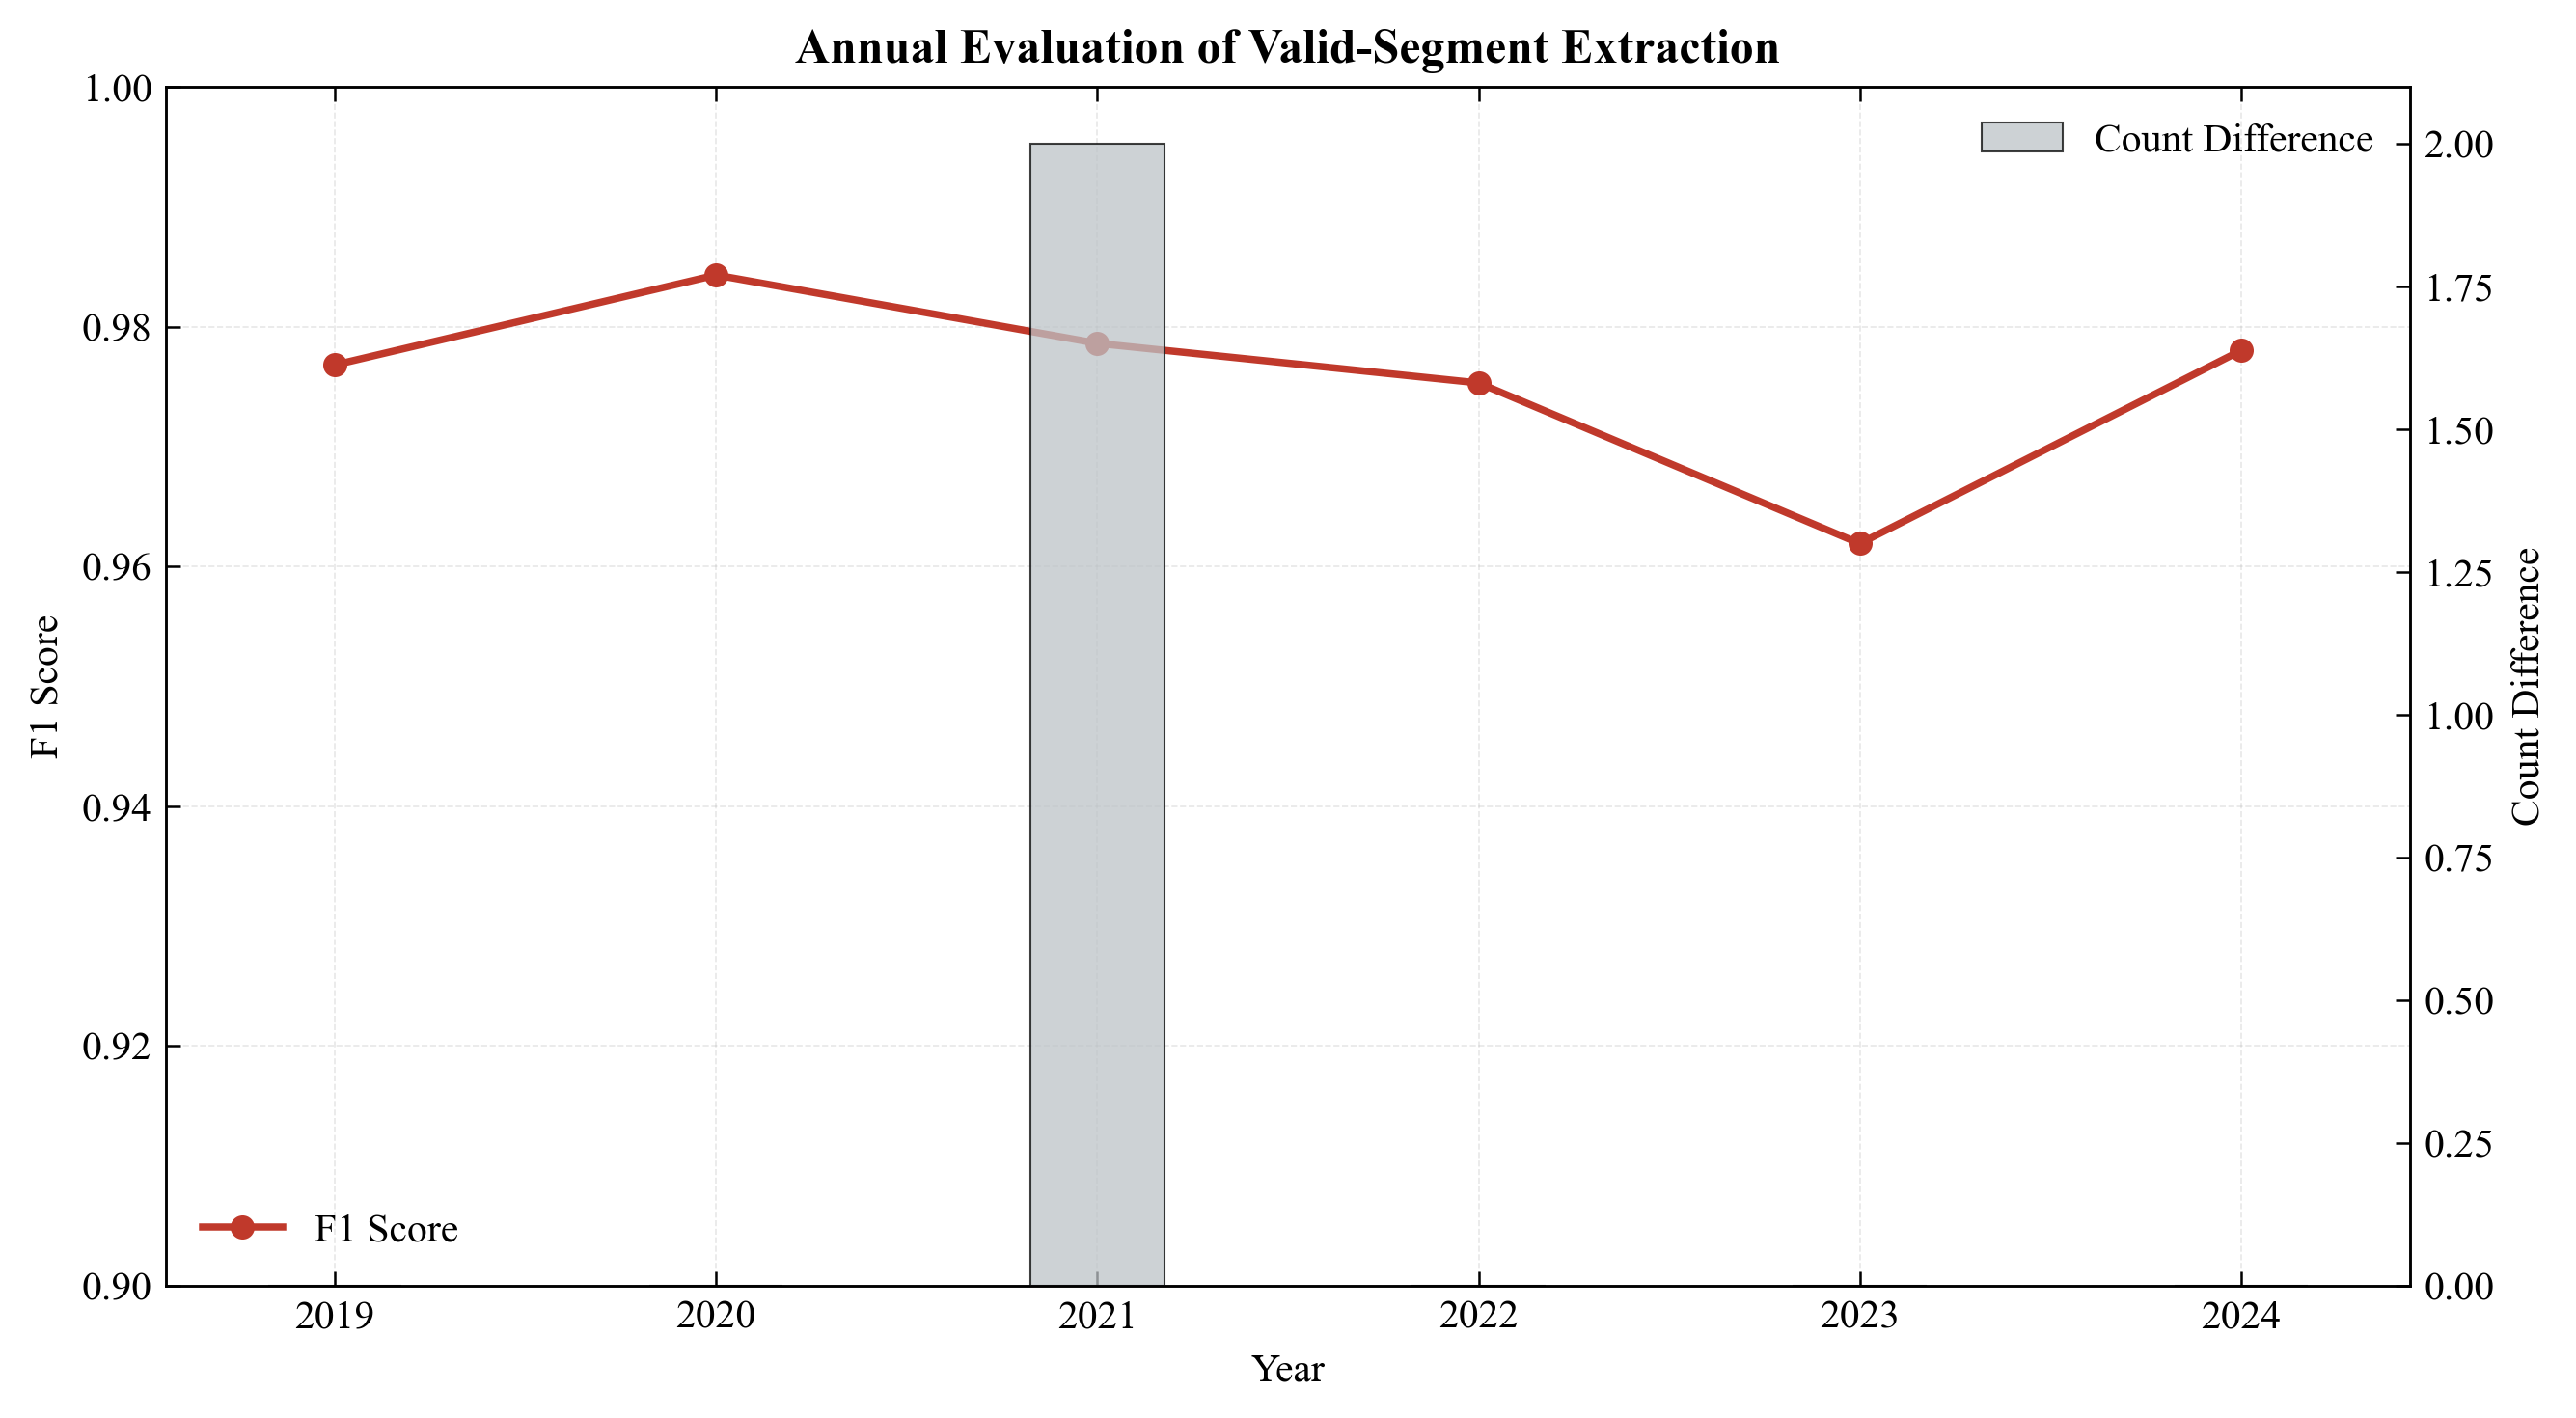

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from ce4_lpr.plotting import apply_paper_style

apply_paper_style()
FIG_DIR = REPO_ROOT / "outputs" / "iou_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)

x = np.arange(len(YEARS))
fig, ax1 = plt.subplots(figsize=(9, 5), dpi=300)
ax1.plot(x, results["F1_Score"], color="#C0392B", marker="o", linewidth=1.8, markersize=5, label="F1 Score")
ax1.set_xticks(x)
ax1.set_xticklabels(YEARS)
ax1.set_ylim(0.90, 1.00)
ax1.set_xlabel("Year")
ax1.set_ylabel("F1 Score")
ax1.grid(True, linestyle="--", linewidth=0.4)
ax1.legend(loc="lower left", frameon=False)

ax2 = ax1.twinx()
ax2.bar(x, results["Count_Diff"], width=0.35, color="#BDC3C7", alpha=0.75, edgecolor="black", linewidth=0.5, label="Count Difference")
ax2.set_ylabel("Count Difference")
ax2.legend(loc="upper right", frameon=False)

plt.title("Annual Evaluation of Valid-Segment Extraction", fontweight="bold")
plt.tight_layout()
fig_path = FIG_DIR / "annual_f1_count_difference.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved figure:", fig_path)
plt.show()
